In [1]:
import numpy as np
import matplotlib.pylab as plt
import pickle

In [7]:
import openpmd_api as opmd


In [ ]:
# In[18]:
if sys.version_info[0] < 3:
    Ref = pickle.load(open(RefFile,"rb"))
    Test = pickle.load(open(TestFile,"rb"))
else:
    Ref = pickle.load(open(RefFile,"rb"),encoding='latin1')
    Test = pickle.load(open(TestFile,"rb"),encoding='latin1')


# In[31]:

test_terms = list(Test["WW"].keys())

for Term in Ref["WW"].keys():
    if Term not in Test["WW"].keys():
        print('missing',Term,'in test set.')
        continue
    else:
        print("Checking...",Term)
        test_terms.remove(Term)

    for KBin in Ref["WW"][Term]['AnyToAny'].keys():
        for QBin in Ref["WW"][Term]['AnyToAny'][KBin].keys():
            np.testing.assert_allclose(Ref["WW"][Term]['AnyToAny'][KBin][QBin],
                                       Test["WW"][Term]['AnyToAny'][KBin][QBin],
                                       rtol=1e-14,atol=1e-7
                                      )    

In [13]:
def k_to_bin(k):
    for this_bin in bins_sorted:
        low, up = this_bin.split('-')
        if k > float(low) and k <= float(up):
            return this_bin
    return None


bins_sorted = ['0.00-3.36',
 '3.36-4.00',
 '4.00-4.76',
 '4.76-5.66',
 '5.66-6.73',
 '6.73-8.00',
 '8.00-9.51',
 '9.51-11.31',
 '11.31-13.45',
 '13.45-16.00',
 '16.00-19.03',
 '19.03-22.63',
 '22.63-26.91',
 '26.91-32.00',
 '32.00-38.05',
 '38.05-45.25',
 '45.25-53.82',
 '53.82-64.00',
 '64.00-76.11',
 '76.11-90.51',
 '90.51-107.63',
 '107.63-128.00',
 '128.00-152.22',
 '152.22-181.02',
 '181.02-215.27',
 '215.27-256.00',
 '256.00-304.44',
 '304.44-362.04',
 '362.04-430.54',
 '430.54-512.00',
 '512.00-608.87',
 '608.87-724.08',
 '724.08-861.08',
 '861.08-1024.00',
 '1024.00-1217.75',
 '1217.75-1448.15',
 '1448.15-1722.16',
 '1722.16-2048.00']


binstr_sort_fun = lambda key : float(key.split('-')[0])

def bin_to_k(KBin):
    Low, Up = KBin.split("-")

    
    return (float(Up) + float(Low))/2.

#terms_to_process = ['UU','BB','BUT','UBTb','BUPbb', 'UBPbb','PU', 'FU', 'nuU', 'etaB']
#terms_to_process = ['UU','BB','BUT','UBTb','BUPbb', 'UBPbb'] #,'PU', 'FU', 'nuU', 'etaB']
#terms_to_process = ['UU','BB','BUT','UBTb','BUPbb', 'UBPbb','PU', 'FU', 'nuU', 'etaB', 'nuDivU', 'nuUreal', 'etaBreal', 'nuDivUreal']
#terms_to_process = ['UU','BB','BUT','UBTb','BUPbb', 'UBPbb','PU', 'nuU', 'etaB', 'nuDivU']


In [55]:
data_ref = pickle.load(open("0024-All-Forc-Pres-testing-128_HDF-gold.pkl","rb"),encoding='latin1')

In [30]:
print(data_ref["WW"].keys())

dict_keys(['BUPbb', 'UBPbb', 'UBTbTot', 'UBTbA', 'BB', 'UBTbC', 'UU', 'UBTa', 'BUP', 'UBPbTot', 'BBC', 'BBA', 'UBTb', 'UBPb', 'BUT', 'UBPbA', 'UBPbC', 'UUA', 'PU', 'UUC', 'FU'])


In [56]:

indata = data_ref # pickle.load(open(dirname,"rb"))
outdata = {}
cross_data = {}
edot_data = {}
#for term in ["nuDivU"]:
#for term in terms_to_process: # + ['nu2U', 'eta2B']:
for term in ["UU", "BB", "BUT"]:
    entrans_data = indata["WW"][term]["AnyToAny"]
    bins = sorted(entrans_data.keys(), key=binstr_sort_fun)
    
    bin_edges = [1]
    for k, k_bin in enumerate(sorted(entrans_data.keys(), key=binstr_sort_fun)):
        bin_edges.append(float(k_bin.split('-')[1]))
    bin_center = np.exp(0.5 * (np.log(bin_edges[1:]) + np.log(bin_edges[:-1])))
    
    outdata[term] = np.zeros([len(bins),len(bins)]) * np.nan
    for k, k_bin in enumerate(sorted(entrans_data.keys(), key=binstr_sort_fun)):                
        for q, q_bin in enumerate(sorted(entrans_data.keys(), key=binstr_sort_fun)):
            outdata[term][k,q] = entrans_data[k_bin][q_bin]
    if (np.isnan(outdata[term]).any()):
        print("help, missing outdata data")

In [57]:
outdata["UU"]

array([[-5.89463214e+02,  4.08372364e+06, -1.01209502e+07,
        -1.59337406e+06, -1.53081450e+05, -1.90289802e+05],
       [-4.08270055e+06,  9.62334134e+03, -4.78539745e+07,
        -2.41694383e+06, -2.09497906e+05, -2.85904268e+05],
       [ 1.01996836e+07,  4.81938623e+07,  2.48613801e+06,
        -3.88520551e+07, -1.51463379e+06, -1.80678282e+06],
       [ 1.61941507e+06,  2.48088708e+06,  4.11853805e+07,
         1.75270020e+06, -7.76197495e+06, -4.80063867e+06],
       [ 1.55536577e+05,  2.13962831e+05,  1.78134526e+06,
         8.25984447e+06,  3.06745822e+04, -4.14754359e+06],
       [ 1.94199250e+05,  2.94826945e+05,  2.19148639e+06,
         5.46032183e+06,  4.32061697e+06,  1.05516369e+05]])

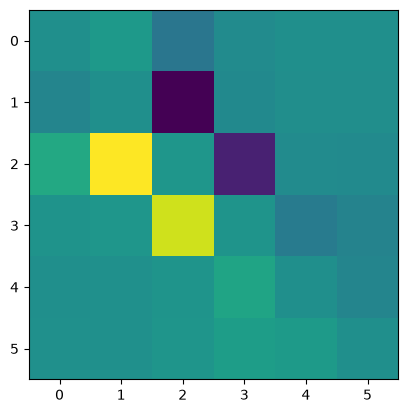

In [59]:
plt.imshow(outdata["UU"]/outdata["UU"].max())

In [53]:

s = opmd.Series("transfer.bp", opmd.Access.read_only)
it = s.iterations[0]
shell_edges = it.get_attribute("shell_edges")
n_shells = it.get_attribute("n_shells")
newdata = {}
newdata["UU"] = it.meshes["UU"][opmd.Mesh_Record_Component.SCALAR].load_chunk()
newdata["BB"] = it.meshes["BB"][opmd.Mesh_Record_Component.SCALAR].load_chunk()
newdata["BUT"] = it.meshes["BUT"][opmd.Mesh_Record_Component.SCALAR].load_chunk()
s.flush()

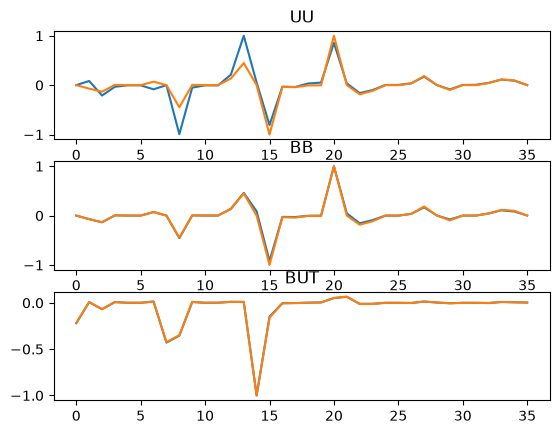

In [58]:
fig, axs = plt.subplots(3,1)

for i, term in enumerate(["UU", "BB","BUT"]):
    
    axs[i].plot((outdata[term]/np.abs(outdata[term]).max()).ravel())
    axs[i].plot((newdata[term]/np.abs(newdata[term]).max()).ravel())
    axs[i].set_title(term)

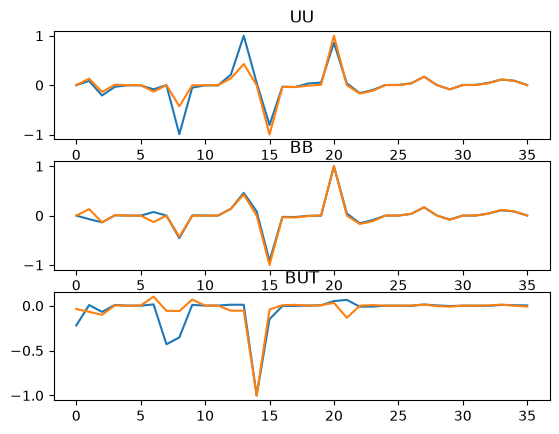

In [52]:
fig, axs = plt.subplots(3,1)

for i, term in enumerate(["UU", "BB","BUT"]):
    
    axs[i].plot((outdata[term]/np.abs(outdata[term]).max()).ravel())
    axs[i].plot((newdata[term]/np.abs(newdata[term]).max()).ravel())
    axs[i].set_title(term)

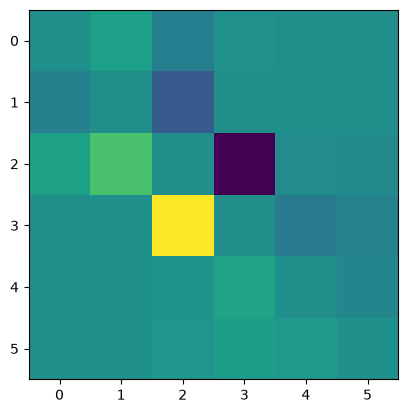

In [60]:
plt.imshow(BB/BB.max())

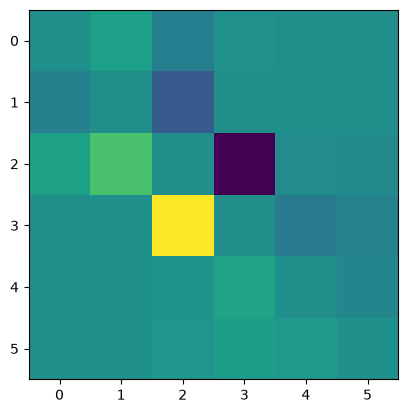

In [41]:
plt.imshow(UU/UU.max())

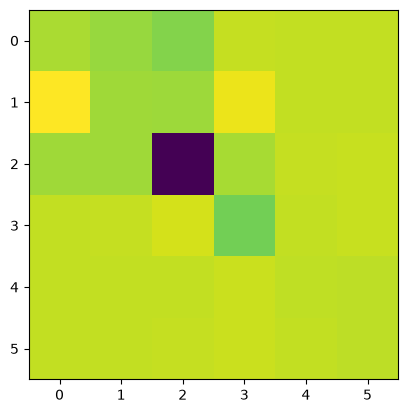

In [40]:
plt.imshow(BUT/BUT.max())

In [21]:
(outdata["UU"]/outdata["UU"].max())/(UU/UU.max())

array([[-1.86628259e+09,  5.45856137e-01,  6.14341142e-01,
         7.99932286e-01,  1.19838713e+00,  1.34325191e+00],
       [ 5.45719386e-01, -3.46998776e+11,  9.92947486e-01,
         1.21617509e+00,  1.64140168e+00,  1.94614594e+00],
       [ 6.19120257e-01,  1.00000000e+00,  1.28014031e+06,
         1.29204213e+00,  1.33681860e+00,  1.56374451e+00],
       [ 8.13005833e-01,  1.24835051e+00,  1.36281027e+00,
         4.18957030e+00,  1.41430022e+00,  1.49480846e+00],
       [ 1.21760692e+00,  1.67638406e+00,  1.38129185e+00,
         1.40844480e+00,  4.32855751e-01,  1.52663222e+00],
       [ 1.23491567e+00,  1.81296264e+00,  1.25866014e+00,
         1.27421608e+00,  1.36845347e+00,  1.68510859e-01]])

In [42]:
(outdata["UU"]/outdata["UU"].max())/(UU/UU.max())

array([[-1.05499133e+09,  6.43136179e-01,  1.53140281e+00,
        -3.38723161e+00,  3.39325304e+00,  3.38645461e+01],
       [ 6.42975056e-01,  2.10861282e+10,  2.32342506e+00,
         1.00186994e+01,  9.65778494e+00,  4.30878394e+00],
       [ 1.54331598e+00,  2.33992743e+00, -5.88763544e+12,
         8.06161890e-01,  8.94053279e-01,  9.51791992e-01],
       [-3.44259021e+00,  1.02837565e+01,  8.54577296e-01,
        -2.72909762e+14,  9.47772269e-01,  8.59527515e-01],
       [ 3.44767418e+00,  9.86361653e+00,  1.05148689e+00,
         1.00856439e+00,  6.25436604e+12,  1.01308827e+00],
       [ 3.45602832e+01,  4.44325514e+00,  1.15444932e+00,
         9.77640097e-01,  1.05536356e+00,  3.73283219e+08]])

In [43]:
UU

array([[ 2.02562660e-08,  2.30199818e+05, -2.39598129e+05,
         1.70539279e+04, -1.63552766e+03, -2.03714446e+02],
       [-2.30199818e+05,  1.65455276e-08, -7.46691001e+05,
        -8.74594585e+03, -7.86418513e+02, -2.40556720e+03],
       [ 2.39598129e+05,  7.46691001e+05, -1.53086148e-08,
        -1.74720276e+06, -6.14180202e+04, -6.88201286e+04],
       [-1.70539279e+04,  8.74594585e+03,  1.74720276e+06,
        -2.32830644e-10, -2.96906574e+05, -2.02484045e+05],
       [ 1.63552766e+03,  7.86418513e+02,  6.14180202e+04,
         2.96906574e+05,  1.77806214e-10, -1.48420963e+05],
       [ 2.03714446e+02,  2.40556720e+03,  6.88201286e+04,
         2.02484045e+05,  1.48420963e+05,  1.02478543e-05]])

In [22]:
UU/UU.max()

array([[ 6.55371529e-15,  1.55233845e-01, -3.41837697e-01,
        -4.13307022e-02, -2.65053593e-03, -2.93945160e-03],
       [-1.55233845e-01, -5.75448172e-16, -1.00000000e+00,
        -4.12362080e-02, -2.64833597e-03, -3.04827049e-03],
       [ 3.41837697e-01,  1.00000000e+00,  4.02972979e-08,
        -6.23943966e-01, -2.35095020e-02, -2.39744372e-02],
       [ 4.13307022e-02,  4.12362080e-02,  6.27069898e-01,
         8.68053358e-03, -1.13877755e-01, -6.66379669e-02],
       [ 2.65053593e-03,  2.64833597e-03,  2.67590642e-02,
         1.21685914e-01,  1.47042789e-03, -5.63721762e-02],
       [ 3.26301082e-03,  3.37432247e-03,  3.61275546e-02,
         8.89167187e-02,  6.55124739e-02,  1.29927240e-02]])

In [23]:
UU.max()

np.float64(455183.43259774626)

(array([1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 8., 0., 1., 1., 4., 5., 3., 4., 0., 2., 4.]),
 array([-1.52399938e+01, -1.50018689e+01, -1.47637440e+01, -1.45256191e+01,
        -1.42874942e+01, -1.40493693e+01, -1.38112444e+01, -1.35731195e+01,
        -1.33349946e+01, -1.30968697e+01, -1.28587448e+01, -1.26206199e+01,
        -1.23824950e+01, -1.21443700e+01, -1.19062451e+01, -1.16681202e+01,
        -1.14299953e+01, -1.11918704e+01, -1.09537455e+01, -1.07156206e+01,
        -1.04774957e+01, -1.02393708e+01, -1.00012459e+01, -9.76312102e+00,
        -9.52499612e+00, -9.28687121e+00, -9.04874631e+00, -8.81062141e+00,
        -8.57249650e+00, -8.33437160e+00, -8.09624670e+00, -7.85812180e+00,
        -7.61999689e+00, -7.38187199e+00, -7.14374709e+00, -6.90562218e+00,
        -6.66749728e+00, -

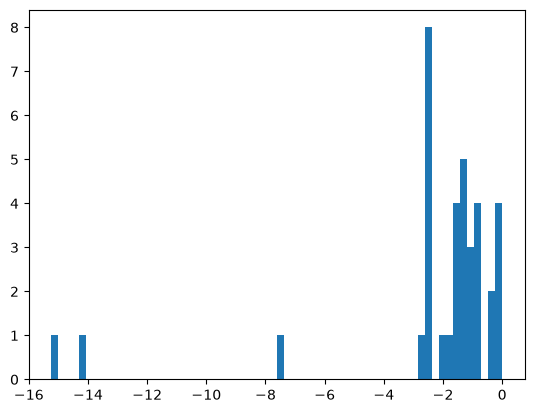

In [28]:
plt.hist(np.log10(np.abs(UU/UU.max())).ravel(),bins=64)

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 2., 2., 2.,
        1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 3., 3., 1., 3., 0., 0., 5.,
        1., 0., 1., 1., 2., 0., 0., 0., 0., 0., 0., 1., 3.]),
 array([-4.91253502, -4.83577666, -4.75901831, -4.68225995, -4.60550159,
        -4.52874323, -4.45198487, -4.37522651, -4.29846815, -4.22170979,
        -4.14495143, -4.06819307, -3.99143471, -3.91467635, -3.83791799,
        -3.76115963, -3.68440127, -3.60764291, -3.53088455, -3.45412619,
        -3.37736783, -3.30060947, -3.22385111, -3.14709275, -3.07033439,
        -2.99357603, -2.91681767, -2.84005931, -2.76330095, -2.68654259,
        -2.60978423, -2.53302587, -2.45626751, -2.37950915, -2.30275079,
        -2.22599243, -2.14923407, -2.07247571, -1.99571735, -1.91895899,
        -1.84220063, -1.76544227, -1.68868391, -1.61192555, -1.5351672 ,
        -1.45840884, -1.38165048, -1.30489212, -1.228

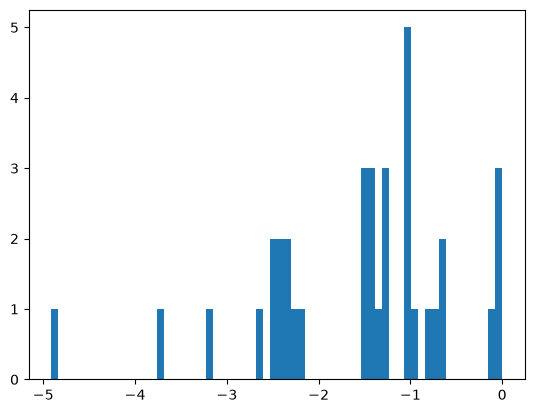

In [29]:
plt.hist(np.log10(np.abs(outdata["UU"]/outdata["UU"].max())).ravel(),bins=64)